In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
from google.colab import files
uploaded = files.upload()  # Upload archive.zip

# Extract the uploaded zip file
with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall("leaf_dataset")


Saving archive.zip to archive.zip


In [3]:
base_dir = "leaf_dataset"

# Print folder and file structure
for root, dirs, files in os.walk(base_dir):
    print(root, ":", len(files), "files")


leaf_dataset : 3 files
leaf_dataset/train : 0 files
leaf_dataset/train/labels : 645 files
leaf_dataset/train/images : 645 files
leaf_dataset/valid : 0 files
leaf_dataset/valid/labels : 61 files
leaf_dataset/valid/images : 61 files
leaf_dataset/test : 0 files
leaf_dataset/test/labels : 31 files
leaf_dataset/test/images : 31 files


In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,  # 20% validation
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

img_size = (128, 128)
batch_size = 32

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 590 images belonging to 3 classes.
Found 147 images belonging to 3 classes.


In [5]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
epochs = 10

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 408ms/step - accuracy: 0.8042 - loss: 0.7660 - val_accuracy: 0.8776 - val_loss: 0.4748
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 254ms/step - accuracy: 0.8806 - loss: 0.5057 - val_accuracy: 0.8776 - val_loss: 0.4652
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 215ms/step - accuracy: 0.8859 - loss: 0.4656 - val_accuracy: 0.8776 - val_loss: 0.4594
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 209ms/step - accuracy: 0.8706 - loss: 0.5042 - val_accuracy: 0.8776 - val_loss: 0.4998
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 270ms/step - accuracy: 0.8778 - loss: 0.5109 - val_accuracy: 0.8776 - val_loss: 0.4559
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 215ms/step - accuracy: 0.8973 - loss: 0.4396 - val_accuracy: 0.8776 - val_loss: 0.5022
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 241ms/step - accuracy: 0.8827 - loss: 0.4736 - val_accuracy: 0.8776 - val_loss: 0.4934
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 240ms/step - accuracy: 0.8716 - loss: 0.4813 - val_accuracy: 0

In [7]:
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation Accuracy: {val_acc*100:.2f}%")


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - accuracy: 0.8594 - loss: 0.5195
Validation Accuracy: 87.76%


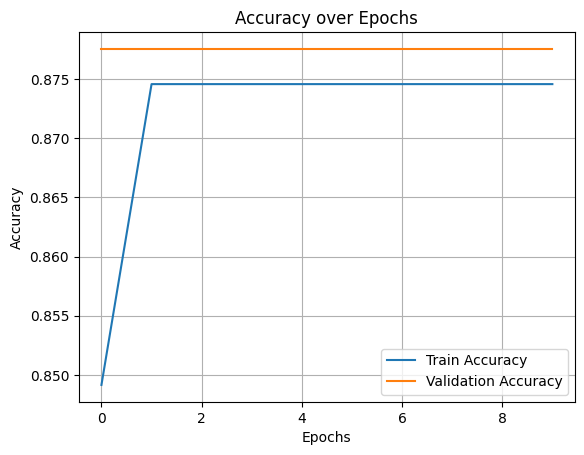

In [8]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()




In [ ]:
#model.save("crop_disease_model.h5")
#print("Model saved as crop_disease_model.h5")


Model saved as crop_disease_model.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step
Classification Report:
               precision    recall  f1-score   support

        test       0.00      0.00      0.00         6
       train       0.88      1.00      0.93       129
       valid       0.00      0.00      0.00        12

    accuracy                           0.88       147
   macro avg       0.29      0.33      0.31       147
weighted avg       0.77      0.88      0.82       147



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


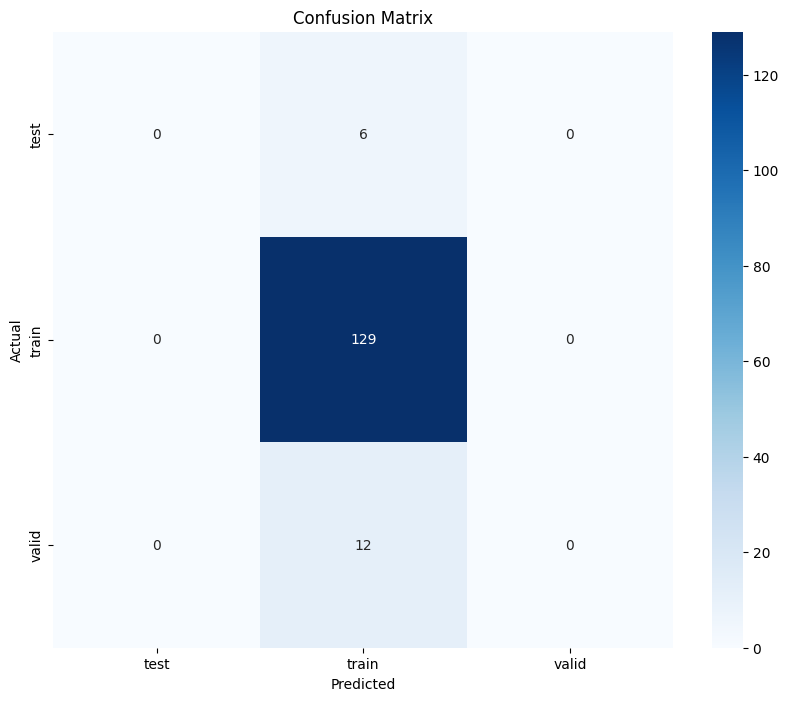

In [9]:

val_generator.reset()
Y_pred = model.predict(val_generator, verbose=1)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes


class_labels = list(val_generator.class_indices.keys())


cm = confusion_matrix(y_true, y_pred)
cr = classification_report(y_true, y_pred, target_names=class_labels)

print("Classification Report:\n", cr)

# Optional: Display confusion matrix as heatmap
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
